In [7]:
import requests
import json
import os
from dotenv import load_dotenv

load_dotenv()
pat = os.getenv("pat")

GENMOL_URL = "https://boc42qqb-sfsenorthamerica-cguzman-aws-us-west-2.snowflakecomputing.app/generate"

headers = {
    "Content-Type": "application/json",
    "Authorization": f'Snowflake Token="{pat}"',
}

# De novo generation - no input SMILES, generates random valid molecules
payload = {
    "num_molecules": 10,
    "temperature": 1.0,
    "noise": 1.0,
    "scoring": "QED",
    "unique": True,
}

response = requests.post(GENMOL_URL, headers=headers, json=payload)
result = response.json()

print(json.dumps(result, indent=2))

{
  "status": "success",
  "molecules": [
    {
      "smiles": "O=C(Nc1ccncc1Cl)c1ccc2c(c1)CCCC2",
      "score": 0.911
    },
    {
      "smiles": "O=C(Nc1ccc(Br)cn1)c1cc(F)cc2c1OCCO2",
      "score": 0.902
    },
    {
      "smiles": "Cc1nc(C)c(C(=O)N2CCN(C(=O)Nc3ncc(C)s3)CC2)o1",
      "score": 0.896
    },
    {
      "smiles": "O=C([O-])CC1CCN(C(=O)C(=O)Nc2ccc(Br)cc2)CC1",
      "score": 0.798
    },
    {
      "smiles": "Cc1ccc(C(=O)N2CCSC(C)C2C)cn1",
      "score": 0.767
    },
    {
      "smiles": "C[C@@H]1CCCCN1C(=O)c1cccc(C(F)(F)F)c1",
      "score": 0.762
    },
    {
      "smiles": "Cn1c(Cc2ccccc2N2CCCC2)nnc1-c1ccccc1",
      "score": 0.736
    },
    {
      "smiles": "c1ccc(COc2cccc(-c3nc4ccccc4[nH]3)c2)cc1",
      "score": 0.587
    },
    {
      "smiles": "CC(C)(C)c1ccccc1",
      "score": 0.511
    },
    {
      "smiles": "C[C@H](SCc1cccc(Br)c1)C(O)=Nc1ccccc1Cl",
      "score": 0.505
    }
  ]
}


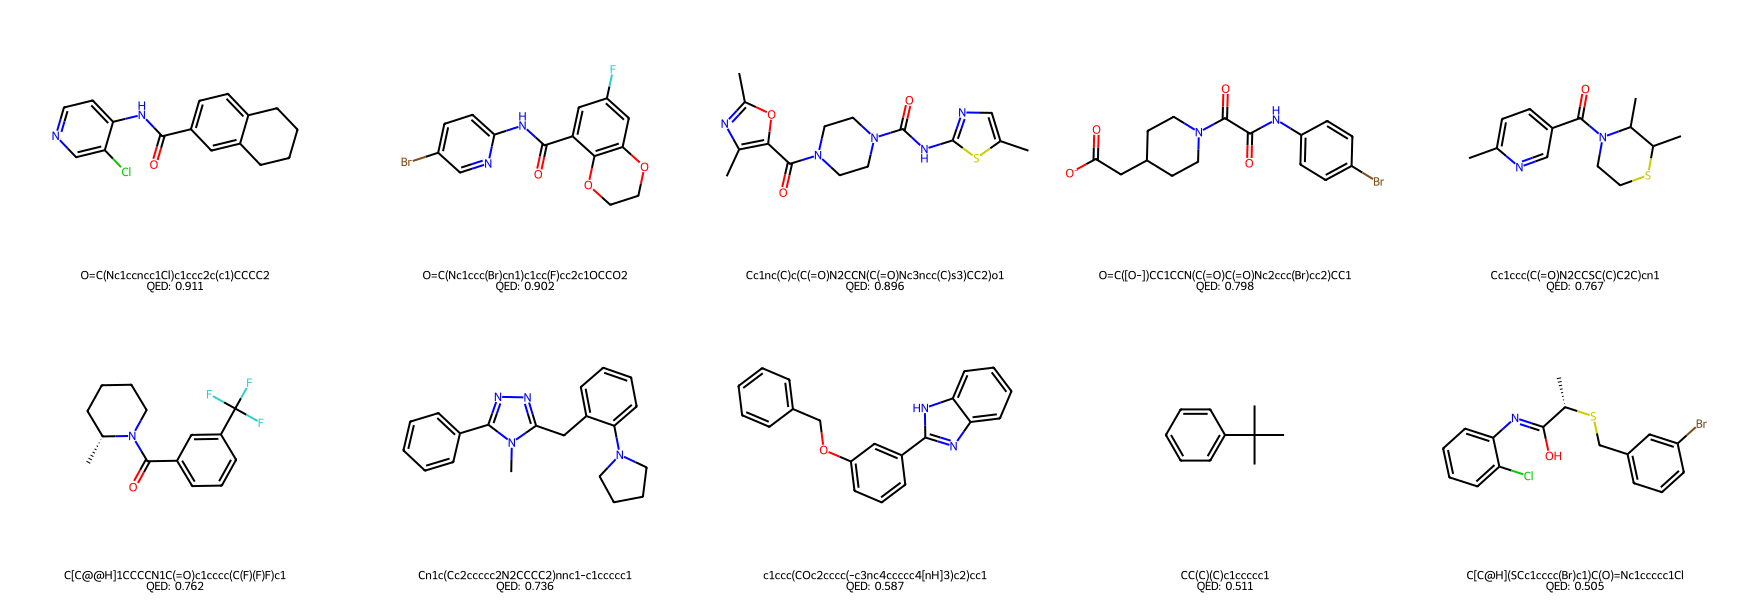

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

molecules = result["molecules"]
mols = [(Chem.MolFromSmiles(m["smiles"]), f'{m["smiles"]}\nQED: {m["score"]:.3f}') for m in molecules]
mols = [(mol, label) for mol, label in mols if mol is not None]

img = Draw.MolsToGridImage(
    [m[0] for m in mols],
    legends=[m[1] for m in mols],
    molsPerRow=5,
    subImgSize=(350, 300),
)
display(img)